# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [0]:
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

import numpy as np

### Change directory

In [83]:
#Come to the home directory
%cd /content

/content


In [84]:
#Create a folder for your project e.g in this case, pascal voc. You can choose any name for the folder 
!mkdir racoon

#Go to the project folder
%cd racoon

mkdir: cannot create directory ‘racoon’: File exists
/content/racoon


In [85]:
#Mount Google drive
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [0]:
!cp '/gdrive/My Drive/AIML/Advanced Computer Vision/ExternalLab/images_racoon.rar' .

In [79]:
!pip install patool
#!pip install pyunpack

In [87]:
import patoolib
patoolib.extract_archive("images_racoon.rar", outdir=".")


patool: Extracting images_racoon.rar ...
patool: running /usr/bin/unrar x -- /content/racoon/images_racoon.rar
patool:     with cwd='.'


PatoolError: ignored

In [88]:
cd images

/content/racoon/images


In [89]:
ls -l

total 13444
drwxr-xr-x 2 root root  12288 Apr 21  2019 images/
-rw-r--r-- 1 root root 118176 Apr 20  2019 raccoon-100.jpg
-rw-r--r-- 1 root root 124554 Apr 20  2019 raccoon-101.jpg
-rw-r--r-- 1 root root  17123 Apr 20  2019 raccoon-102.jpg
-rw-r--r-- 1 root root 173619 Apr 20  2019 raccoon-103.jpg
-rw-r--r-- 1 root root  41618 Apr 20  2019 raccoon-104.jpg
-rw-r--r-- 1 root root  99844 Apr 20  2019 raccoon-105.jpg
-rw-r--r-- 1 root root  13337 Apr 20  2019 raccoon-106.jpg
-rw-r--r-- 1 root root  95486 Apr 20  2019 raccoon-107.jpg
-rw-r--r-- 1 root root  92585 Apr 20  2019 raccoon-108.jpg
-rw-r--r-- 1 root root  18709 Apr 20  2019 raccoon-109.jpg
-rw-r--r-- 1 root root  70541 Apr 20  2019 raccoon-10.jpg
-rw-r--r-- 1 root root  13357 Apr 20  2019 raccoon-110.jpg
-rw-r--r-- 1 root root 137606 Apr 20  2019 raccoon-111.jpg
-rw-r--r-- 1 root root 162431 Apr 20  2019 raccoon-112.jpg
-rw-r--r-- 1 root root 249753 Apr 20  2019 raccoon-113.jpg
-rw-r--r-- 1 root root  88708 Apr 20  2019 raccoon-11

### Load the training data from train.csv file

In [90]:
#Come to the home directory
%cd /content

/content


In [91]:
ls -l

total 16
drwxr-xr-x 3 root root 4096 Nov 10 09:06 racoon/
drwxr-xr-x 1 root root 4096 Nov  6 16:17 sample_data/
-rw------- 1 root root 7913 Nov 10 09:06 train_labels.csv


In [0]:
!cp '/gdrive/My Drive/AIML/Advanced Computer Vision/ExternalLab/train_labels.csv' .

In [93]:
import pandas as pd
df = pd.read_csv('train_labels.csv')
df.head(5)

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


### Print the shape of the train dataset

In [94]:
df.shape

(173, 8)

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
IMAGE_SIZE = 128

In [0]:
#We will use opencv and matplotlib
from matplotlib import pyplot as plt
import cv2
import numpy as np

In [0]:
#Pickup a random image number
img_num = np.random.randint(0, df.shape[0])

#Read the image
img_file = df.loc[img_num,'filename']
img = cv2.imread('racoon/images/' + img_file)

#Find all rows which have same file name
rows_with_file = df[df['filename'] == img_file].index.tolist()

#Draw rectangle(s) as per bounding box information
for i in rows_with_file:

    #Get bounding box
    xmin, ymin, xmax, ymax = df.loc[i, ['xmin', 'ymin', 'xmax', 'ymax']]
    #Get Label
    label = df.loc[i, 'class']
    #Add bounding box
    cv2.rectangle(img, (xmin,ymin), (xmax, ymax), (0,255,0), 2)
    #Add text
    cv2.putText(img,label,(xmin, ymin-5),cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Draw image using matplotlib
plt.figure(figsize=(10,5))
plt.imshow(img)
plt.show()

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [0]:
import csv
from sklearn.preprocessing import LabelBinarizer

path = []

with open('train_labels.csv','r') as csvfile:
    plots = csv.reader(csvfile, delimiter=',')
    next(plots, None)  # skip the headers
    for row in plots:
        filepath = '/content/racoon/images/' + str(row[0])
        path.append(filepath)        

In [99]:
path[1]

'/content/racoon/images/raccoon-11.jpg'

In [100]:
coords = np.zeros((len(path), 4))
coords.shape


(173, 4)

In [0]:
for i in range(0, len(path)):
    image_width=df.loc[i,'width'].astype('int32')
    image_height=df.loc[i,'height'].astype('int32')
    x0=df.loc[i,'xmin'].astype('int32')
    y0=df.loc[i,'ymin'].astype('int32')
    x1=df.loc[i,'xmax'].astype('int32')
    y1=df.loc[i,'ymax'].astype('int32')
    coords[i, 0] = x0 * IMAGE_SIZE / image_width # Normalize bounding box by image size
    coords[i, 1] = y0 * IMAGE_SIZE / image_height # Normalize bounding box by image size
    coords[i, 2] = (x1 - x0) * IMAGE_SIZE / image_width # Normalize bounding box by image size
    coords[i, 3] = (y1 - y0) * IMAGE_SIZE / image_height # Normalize bounding box by image size

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [0]:
from PIL import Image
from sklearn import preprocessing
from keras.applications.mobilenet import MobileNet, preprocess_input

batch_images = np.zeros((len(path), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
for i in range(0,len(path)):
    img = Image.open(path[i]) # Read image
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE)) # Resize image
    img = img.convert('RGB')
    batch_images[i] = preprocess_input(np.array(img, dtype=np.float32))
    
        

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


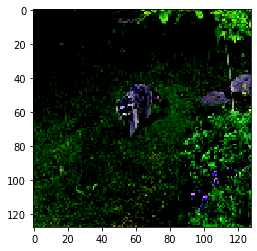

In [103]:
#Showing the first image from the array
plt.imshow(batch_images[0])
plt.show()

In [0]:
X = batch_images
Y = coords

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X , Y , test_size=0.4 )

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [0]:
from keras.applications import MobileNet
from keras.applications.mobilenet import preprocess_input

In [0]:
model = MobileNet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, alpha=1) 

In [0]:
#Set pre-trained model layers to not trainable
for layer in model.layers:
    layer.trainable = False

In [0]:
from keras.models import Model
from keras.layers import Conv2D, Reshape, MaxPooling2D

#Adding Layers
x = model.layers[-1].output
x = Conv2D(4, kernel_size=4, name="coords")(x)
x = Reshape((4,))(x) #Predictions of coordinates

In [0]:
model = Model(inputs=model.input, outputs=x)

In [111]:
model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 129, 129, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 64, 64, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 64, 64, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 64, 64, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 64, 64, 32)        128 

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
from keras.backend import epsilon

def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou



In [0]:
def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [0]:
model.compile(optimizer='Adam', loss='mse', metrics=[IoU])

In [131]:
model.fit( X_train , y_train, validation_data=( X_test , y_test ),epochs=10 ,batch_size=32 )

Train on 103 samples, validate on 70 samples
Epoch 1/10
103/103 [==============================] - 7s 72ms/step - loss: 356.2079 - IoU: 0.5494 - val_loss: 403.8734 - val_IoU: 0.5761
Epoch 2/10
103/103 [==============================] - 5s 50ms/step - loss: 210.6793 - IoU: 0.6540 - val_loss: 402.8447 - val_IoU: 0.5811
Epoch 3/10
103/103 [==============================] - 5s 49ms/step - loss: 152.8443 - IoU: 0.7041 - val_loss: 380.6268 - val_IoU: 0.6066
Epoch 4/10
103/103 [==============================] - 5s 50ms/step - loss: 120.1316 - IoU: 0.7361 - val_loss: 394.6521 - val_IoU: 0.5996
Epoch 5/10
103/103 [==============================] - 5s 50ms/step - loss: 88.6627 - IoU: 0.7742 - val_loss: 434.9657 - val_IoU: 0.6036
Epoch 6/10
103/103 [==============================] - 5s 50ms/step - loss: 79.1577 - IoU: 0.7873 - val_loss: 403.3658 - val_IoU: 0.6022
Epoch 7/10
103/103 [==============================] - 5s 49ms/step - loss: 69.7274 - IoU: 0.8086 - val_loss: 411.6157 - val_IoU: 0.6045

### Pick a test image from the given data

In [0]:
img=Image.open(path[111])

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

In [140]:
img.size

(800, 533)

In [0]:
img_inp=img.resize((128, 128))

In [0]:
img_inp=preprocess_input(np.array(img_inp, dtype=np.float32))

### Predict the coordinates of the bounding box for the given test image

In [0]:
region = model.predict(x=np.array([img_inp]))[0] # Predict the BBox


In [144]:
region

array([ 14.672097,  -3.77557 ,  71.40935 , 128.32167 ], dtype=float32)

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

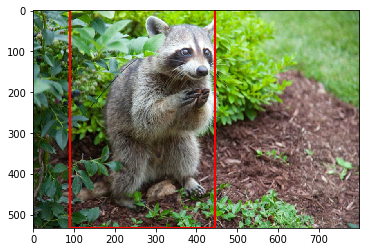

In [145]:
image_width,image_height = img.size
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(img)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()